# Process Downloaded data to Api Format

In [2]:
import pandas as pd

# 1. Load the raw flattened dataset and the players dataset
print("Loading datasets...")
df_raw = pd.read_csv('Data/Downloaded/matchData.csv')
df_players = pd.read_csv('Data/Downloaded/players_8-14-25.csv')

# Filter out remakes/bugs (games under 3 minutes)
df_valid = df_raw[df_raw['gameDuration'] > 180].copy()

# 2. Prep the players dataframe to merge their ranks later
# Combine 'tier' and 'rank' into a single string (e.g., "PLATINUM I")
df_players['full_rank'] = df_players['tier'] + " " + df_players['rank']
df_ranks = df_players[['puuid', 'full_rank']].drop_duplicates(subset=['puuid'])

# 3. Create an empty list to hold our reshaped data
all_match_records = []

print("Reshaping the dataset to match your Riot API format...")

# 4. Loop through all 10 participants
for i in range(10):
    # Map the dataset columns to your exact API dictionary keys
    col_map = {
        'matchId': 'match_id',
        'gameCreation': 'game_start_timestamp',
        'gameEndTimestamp': 'game_end_timestamp',
        'gameDuration': 'game_duration_sec',
        f'participant{i}Puuid': 'puuid',
        f'participant{i}Win': 'win',
        f'participant{i}ChampionName': 'champion_played',
        f'participant{i}Kills': 'kills',
        f'participant{i}Deaths': 'deaths',
        f'participant{i}Assists': 'assists'
    }
    
    # Extract just the columns we need for this participant
    cols_to_extract = list(col_map.keys())
    temp_df = df_valid[cols_to_extract].copy()
    
    # Rename the columns to match your 'parse_match_data' output
    temp_df = temp_df.rename(columns=col_map)
    
    # Add this participant's data to our list
    all_match_records.append(temp_df)

# 5. Combine all 10 chunks into one massive player-centric dataframe
df_clean = pd.concat(all_match_records, ignore_index=True)

# Drop rows where PUUID is somehow missing
df_clean = df_clean.dropna(subset=['puuid'])

print("Merging player ranks and converting timestamps...")

# 6. Merge in the player rank to perfectly match your API output
df_clean = df_clean.merge(df_ranks, on='puuid', how='left')
df_clean = df_clean.rename(columns={'full_rank': 'rank'})

# 7. Replicate your datetime conversion from the original script
df_clean['game_end_datetime'] = pd.to_datetime(df_clean['game_end_timestamp'], unit='ms')

# 8. Sort chronologically by PUUID and Time (Crucial for session tracking)
df_clean = df_clean.sort_values(by=['puuid', 'game_start_timestamp']).reset_index(drop=True)

print(f"Success! Reshaped into {len(df_clean)} perfectly formatted rows.")
display(df_clean.head())

# Optional: Save this cleanly formatted version so you don't have to reshape it every time
df_clean.to_csv("Data/Downloaded/formatted_match_records.csv.gz", index=False, compression='gzip')

Loading datasets...
Reshaping the dataset to match your Riot API format...
Merging player ranks and converting timestamps...
Success! Reshaped into 1004240 perfectly formatted rows.


,match_id,game_start_timestamp,game_end_timestamp,game_duration_sec,puuid,win,champion_played,kills,deaths,assists,rank,game_end_datetime
0,NA1_5327024082,1752733728988,1752735586676,1831,--0Nm-sygIVnbYQfvoOvWbXd29cPSeWmPlRbKdYaGB3W_W...,True,Nami,1,2,25,NaN,2025-07-17 06:59:46.676
1,NA1_5338083917,1754189103540,1754190833193,1709,--128VhI8h9ETlx2AC6bwcqMMeBy6MO_gnXY2fb18vR-PL...,True,Yunara,6,10,17,NaN,2025-08-03 03:13:53.193
2,NA1_5334851602,1753842460864,1753844255461,1653,--28an59iiEzUyEYNW1CO1jkItdltOX7HMC6P8HZy0eEXH...,False,Alistar,1,11,16,NaN,2025-07-30 02:57:35.461
3,NA1_5337262405,1754104805054,1754106340883,1512,--28an59iiEzUyEYNW1CO1jkItdltOX7HMC6P8HZy0eEXH...,True,Jhin,11,7,10,NaN,2025-08-02 03:45:40.883
4,NA1_5337920809,1754177844653,1754179355864,1492,--28an59iiEzUyEYNW1CO1jkItdltOX7HMC6P8HZy0eEXH...,False,Poppy,2,6,2,NaN,2025-08-03 00:02:35.864


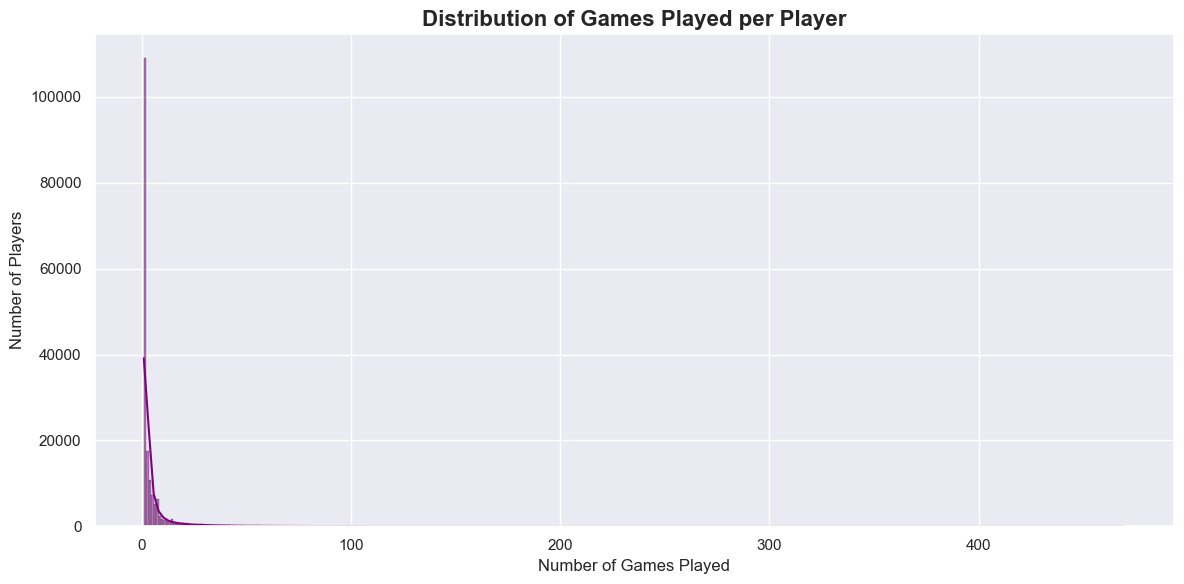

--- Summary Statistics for Games Played ---
Total Unique Players: 178,004
Average Games per Player: 5.6
Median Games per Player: 2.0
Most Games Played by a Single Player: 470
Fewest Games Played by a Single Player: 1


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice visual style
sns.set_theme(style="darkgrid")

# 1. Count the number of games played by each unique player
games_per_player = df_clean['puuid'].value_counts()

# 2. Create the figure
plt.figure(figsize=(12, 6))

# 3. Plot a histogram with a KDE (Kernel Density Estimate) curve
sns.histplot(
    games_per_player, 
    bins=400,            # Adjust the number of bins based on how granular you want it
    kde=True,           # Adds a smooth curve over the bars
    color='purple',
    edgecolor='black'
)

# 4. Add Titles and Labels
plt.title("Distribution of Games Played per Player", fontsize=16, fontweight='bold')
plt.xlabel("Number of Games Played", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)

# 5. Display the plot
plt.tight_layout()
plt.show()

# 6. Print out some quick summary statistics to understand the data better
print("--- Summary Statistics for Games Played ---")
print(f"Total Unique Players: {len(games_per_player):,}")
print(f"Average Games per Player: {games_per_player.mean():.1f}")
print(f"Median Games per Player: {games_per_player.median():.1f}")
print(f"Most Games Played by a Single Player: {games_per_player.max()}")
print(f"Fewest Games Played by a Single Player: {games_per_player.min()}")